# Projekt 03 (final) — Kundensegmentierung · Musterlösung

**Modul 05 — Machine Learning 2 · Unsupervised-Learning-Capstone**

Diese Musterlösung ist vollständig ausgeführt. Sie konsolidiert den unüberwachten Teil des Moduls an **echten Daten** (UCI *Wholesale Customers*, 440 Großhandelskunden eines portugiesischen Distributors) und beantwortet eine konkrete Geschäftsfrage:

> *Der Distributor kennt seine Kunden nur über ihre jährlichen Ausgaben in sechs Produktkategorien. Gibt es natürliche Kundensegmente — und wenn ja, wie viele, wie sehen sie aus, und wie sicher sind wir uns?*

Wir gehen den kompletten Pfad: **EDA → Vorverarbeitung → Dimensionsreduktion (PCA, t-SNE) → vier Clustering-Verfahren (k-Means, GMM/EM, DBSCAN, Ward) → Modellwahl (Silhouette, BIC, ARI) → geschäftliche Interpretation.**

Die entscheidende didaktische Pointe vorweg: Die vier Verfahren **widersprechen sich teilweise**, und genau dieser Widerspruch ist die Lektion. Es gibt keinen "richtigen" Cluster-Algorithmus — es gibt nur Annahmen, die zu den Daten passen oder nicht.

## 0 · Setup und Daten

Die Daten werden lokal nach `datasets/` gecacht (der Ordner ist per `.gitignore` vom Repo ausgeschlossen — echte Daten committen wir nicht). Ist die Datei schon da, wird nicht neu geladen; sonst holen wir sie von UCI (mit `User-Agent`-Header, sonst antwortet der Server mit 406).

Die sechs **kontinuierlichen** Merkmale sind die jährlichen Ausgaben (in Geldeinheiten) für: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.
Die zwei **kategorialen** Spalten halten wir strikt aus dem Clustering heraus und heben sie als *externe Validierung* auf:
- `Channel`: 1 = **Horeca** (Hotel/Restaurant/Café), 2 = **Retail** (Einzelhandel)
- `Region`: 1 = Lissabon, 2 = Porto, 3 = sonstige

`Channel` ist unsere heimliche "Wahrheit": Ein gutes, rein datengetriebenes Clustering sollte diese Geschäftslogik *ohne sie je gesehen zu haben* wiederentdecken.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request

RNG = 42
np.random.seed(RNG)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("daten")
DATA_DIR.mkdir(exist_ok=True)
CSV = DATA_DIR / "wholesale_customers.csv"
URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "00292/Wholesale%20customers%20data.csv")

if not CSV.exists():
    req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
    CSV.write_bytes(urllib.request.urlopen(req, timeout=60).read())
    print("heruntergeladen ->", CSV)

df = pd.read_csv(CSV)
FEATURES = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
print("Shape:", df.shape)
df.head()

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
# Die kategorialen Spalten als externe Labels sichern, dann NUR die 6 Ausgaben behalten.
channel = (df["Channel"].values - 1)      # 0 = Horeca, 1 = Retail
region  = df["Region"].values
X = df[FEATURES].values.astype(float)
print("Channel-Verteilung:", dict(zip(*np.unique(channel, return_counts=True))))  # 0:298 Horeca, 1:142 Retail
df[FEATURES].describe().round(0)

Channel-Verteilung: {np.int64(0): np.int64(298), np.int64(1): np.int64(142)}


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0
std,12647.0,7380.0,9503.0,4855.0,4768.0,2820.0
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3128.0,1533.0,2153.0,742.0,257.0,408.0
50%,8504.0,3627.0,4756.0,1526.0,816.0,966.0
75%,16934.0,7190.0,10656.0,3554.0,3922.0,1820.0
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


## 1 · EDA: Warum wir *nicht* auf den Rohdaten clustern

Sieh dir die Verteilungen an. Alle sechs Merkmale sind **stark rechtsschief** (Median ≪ Mittelwert, Maxima im Bereich des 10–40-fachen des Medians). Der Grund ist inhaltlich: Ausgaben sind multiplikativ (ein Großkunde gibt nicht *100 mehr* aus, sondern *das 100-fache*), und multiplikative Größen sind typischerweise **log-normal** verteilt.

Für distanzbasierte Verfahren (k-Means, Ward) und dichtebasierte Verfahren (DBSCAN) ist das fatal: Die euklidische Distanz wird von den wenigen Riesenkunden dominiert; ein einziger Ausreißer in `Fresh` überstimmt die gesamte Struktur in den kleineren Kategorien. Deshalb: **`log1p`-Transformation** (macht die Verteilungen näherungsweise symmetrisch) **und danach Standardisierung** (z-Score, damit jede Kategorie gleiches Gewicht hat).

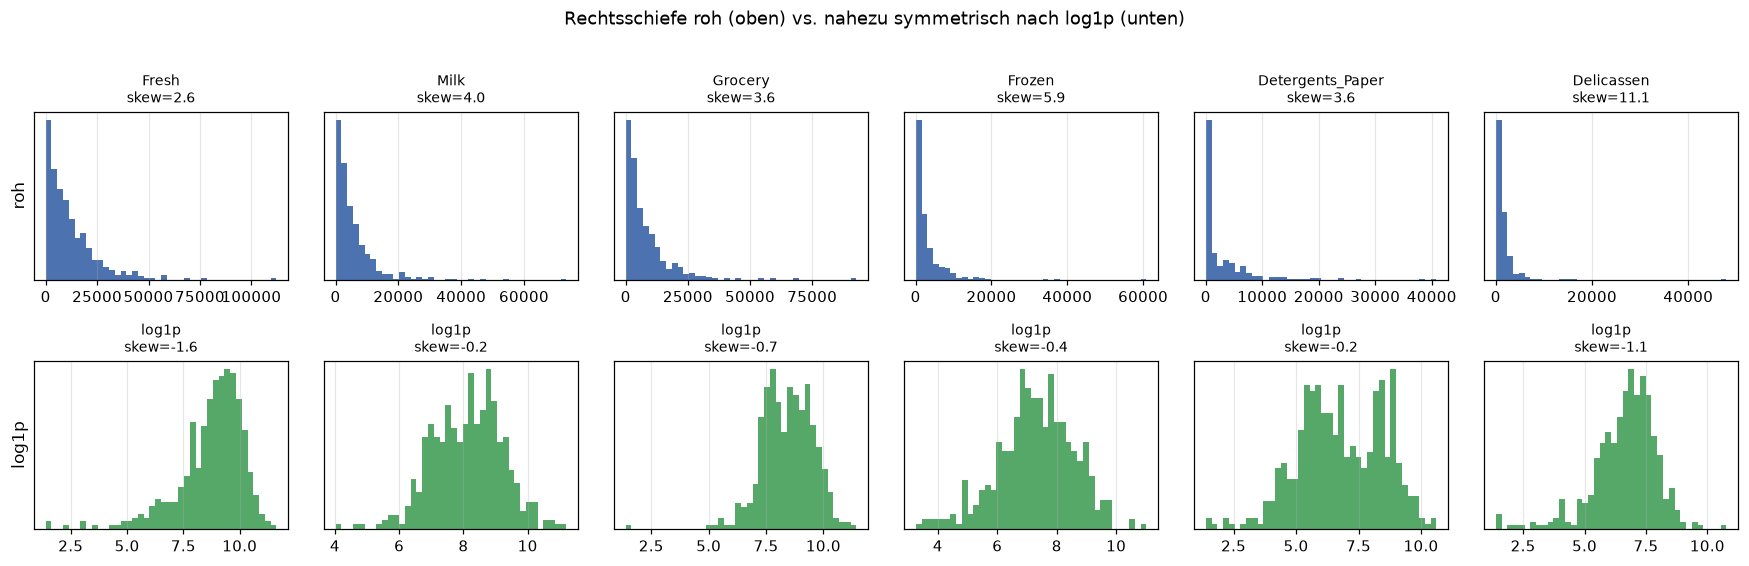

In [3]:
from scipy.stats import skew

fig, axes = plt.subplots(2, 6, figsize=(16, 5))
for j, f in enumerate(FEATURES):
    axes[0, j].hist(X[:, j], bins=40, color="#4C72B0")
    axes[0, j].set_title(f"{f}\nskew={skew(X[:,j]):.1f}", fontsize=9)
    axes[1, j].hist(np.log1p(X[:, j]), bins=40, color="#55A868")
    axes[1, j].set_title(f"log1p\nskew={skew(np.log1p(X[:,j])):.1f}", fontsize=9)
    for r in (0, 1):
        axes[r, j].set_yticks([])
axes[0, 0].set_ylabel("roh", fontsize=11)
axes[1, 0].set_ylabel("log1p", fontsize=11)
fig.suptitle("Rechtsschiefe roh (oben) vs. nahezu symmetrisch nach log1p (unten)", y=1.02)
plt.tight_layout(); plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

X_log = np.log1p(X)
scaler = StandardScaler()
Xs = scaler.fit_transform(X_log)
print("Nach log1p+z-Score:  mean≈", Xs.mean(0).round(2), " std≈", Xs.std(0).round(2))
print("Schiefe vorher (Mittel über Merkmale): %.2f   nachher: %.2f"
      % (np.mean([skew(X[:,j]) for j in range(6)]),
         np.mean([skew(Xs[:,j]) for j in range(6)])))

Nach log1p+z-Score:  mean≈ [ 0. -0. -0.  0. -0. -0.]  std≈ [1. 1. 1. 1. 1. 1.]
Schiefe vorher (Mittel über Merkmale): 5.13   nachher: -0.69


## 2 · Dimensionsreduktion I: PCA

PCA (Skript 2.9) sucht die orthogonalen Richtungen maximaler Varianz. Zwei Ziele hier:
1. **Visualisierung** in 2D, ohne die globale Struktur (anders als t-SNE) zu verzerren.
2. **Interpretation**: Die Ladungen (`components_`) sagen uns, *welche* Ausgaben zusammenhängen.

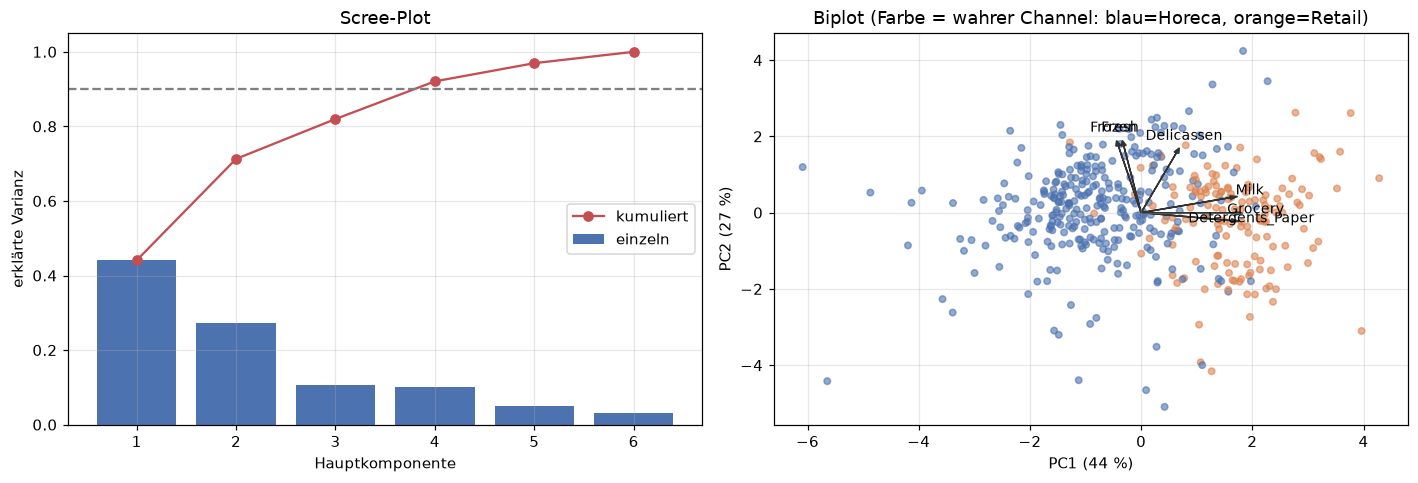

Erklärte Varianz kumuliert: [0.441 0.713 0.82  0.921 0.97  1.   ]
PC1-Ladungen: {'Fresh': np.float64(-0.11), 'Milk': np.float64(0.54), 'Grocery': np.float64(0.57), 'Frozen': np.float64(-0.14), 'Detergents_Paper': np.float64(0.55), 'Delicassen': np.float64(0.21)}
PC2-Ladungen: {'Fresh': np.float64(0.59), 'Milk': np.float64(0.13), 'Grocery': np.float64(-0.01), 'Frozen': np.float64(0.59), 'Detergents_Paper': np.float64(-0.07), 'Delicassen': np.float64(0.53)}


In [5]:
from sklearn.decomposition import PCA

pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
Z = pca.transform(Xs)           # Scores

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.bar(range(1, 7), evr, color="#4C72B0", label="einzeln")
a1.plot(range(1, 7), np.cumsum(evr), "o-", color="#C44E52", label="kumuliert")
a1.axhline(0.9, ls="--", c="grey"); a1.set_xlabel("Hauptkomponente")
a1.set_ylabel("erklärte Varianz"); a1.set_title("Scree-Plot"); a1.legend()

# Biplot: Scores (Kunden) + Ladungspfeile (Merkmale), eingefärbt nach WAHREM Channel
colors = np.where(channel == 0, "#4C72B0", "#DD8452")
a2.scatter(Z[:, 0], Z[:, 1], c=colors, s=18, alpha=0.6)
for j, f in enumerate(FEATURES):
    a2.arrow(0, 0, pca.components_[0, j]*3.2, pca.components_[1, j]*3.2,
             color="#333", head_width=0.09, length_includes_head=True)
    a2.text(pca.components_[0, j]*3.6, pca.components_[1, j]*3.6, f,
            fontsize=9, ha="center", color="black")
a2.set_xlabel(f"PC1 ({evr[0]*100:.0f} %)"); a2.set_ylabel(f"PC2 ({evr[1]*100:.0f} %)")
a2.set_title("Biplot (Farbe = wahrer Channel: blau=Horeca, orange=Retail)")
plt.tight_layout(); plt.show()

print("Erklärte Varianz kumuliert:", np.cumsum(evr).round(3))
print("PC1-Ladungen:", dict(zip(FEATURES, pca.components_[0].round(2))))
print("PC2-Ladungen:", dict(zip(FEATURES, pca.components_[1].round(2))))

**Interpretation der Hauptkomponenten** (die entscheidende inhaltliche Erkenntnis):

- **PC1 (44 % Varianz)** lädt stark und positiv auf `Milk`, `Grocery`, `Detergents_Paper` (Ladungen ≈ 0,54–0,57) — der klassische **Supermarkt-/Retail-Warenkorb**: haltbare Ware, Reinigungsmittel, Papier, Milchprodukte.
- **PC2 (27 % Varianz)** lädt auf `Fresh`, `Frozen`, `Delicassen` (≈ 0,53–0,59) — der **Gastronomie-Warenkorb**: frische und tiefgekühlte Ware, Feinkost.

Schon der Biplot zeigt (an der Färbung nach `Channel`, die die PCA *nie gesehen hat*), dass sich Horeca und Retail entlang **PC1** trennen: Retail-Kunden liegen rechts (hohe Grocery/Detergents-Ausgaben). Die Struktur ist also real und liegt in den Ausgabenmustern — nicht in den Labels. `Detergents_Paper` ist der stärkste Einzeltrenner (bekanntes Resultat für diesen Datensatz).

PC1+PC2 erklären **71 %** der Varianz — eine 2D-Sicht verliert wenig.

## 3 · Dimensionsreduktion II: t-SNE

t-SNE (Skript 2.10) bewahrt **lokale** Nachbarschaften und trennt Blobs oft optisch sauberer, verzerrt aber globale Distanzen und Cluster-Größen — deshalb *nur zur Visualisierung*, nie als Vorstufe fürs Clustering und nie zur Distanzinterpretation. `perplexity` ist der wichtigste Hyperparameter (Größenordnung der berücksichtigten Nachbarschaft).

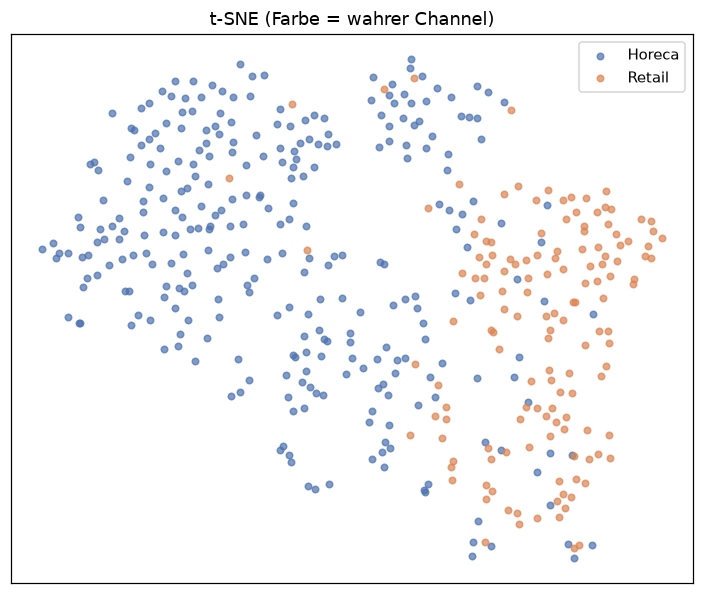

In [6]:
from sklearn.manifold import TSNE

emb = TSNE(n_components=2, perplexity=30, init="pca",
           learning_rate="auto", random_state=RNG).fit_transform(Xs)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for c, name, col in [(0, "Horeca", "#4C72B0"), (1, "Retail", "#DD8452")]:
    m = channel == c
    ax.scatter(emb[m, 0], emb[m, 1], s=18, alpha=0.7, label=name, color=col)
ax.set_title("t-SNE (Farbe = wahrer Channel)"); ax.legend()
ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout(); plt.show()

t-SNE bestätigt: Es gibt **keine mit breiter Lücke getrennten** Cluster. Horeca und Retail bilden zwei überlappende Wolken mit fließendem Übergang. Merke dir dieses Bild — es erklärt später, **warum DBSCAN scheitern muss** und warum die Silhouettenwerte moderat bleiben.

## 4 · k-Means: Modellwahl über Elbow & Silhouette

k-Means (Skript 2.6) minimiert die Within-Cluster-Sum-of-Squares und nimmt implizit **sphärische, gleich große** Cluster an. Wir bestimmen $k$ über zwei Kriterien:
- **Elbow**: Inertia (WCSS) über $k$ — Knick suchen.
- **Silhouette**: mittlere Silhouette $s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}\in[-1,1]$; höher ist besser, unabhängig von der Skala.

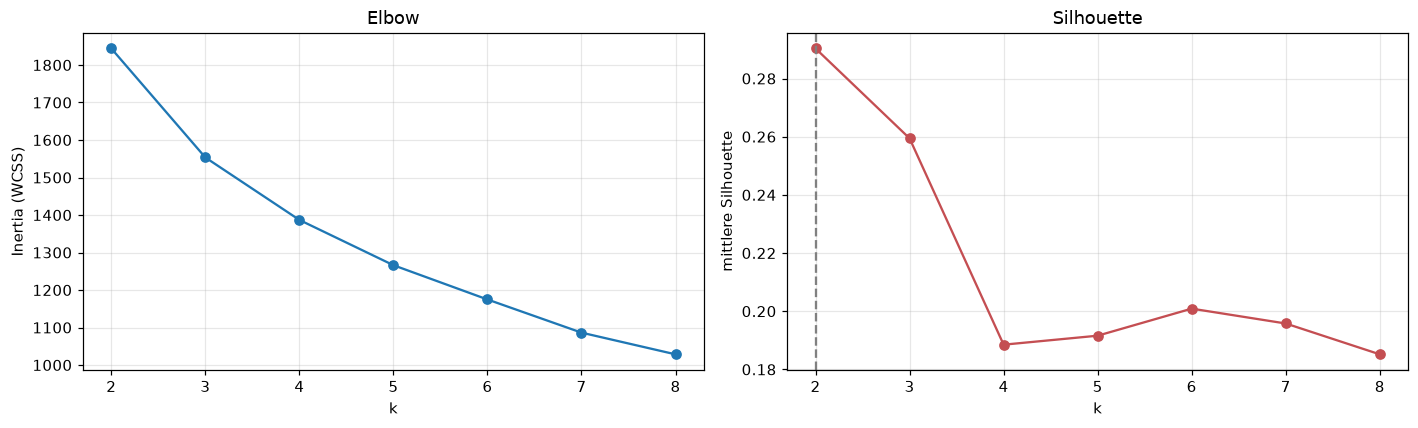

k=2: Silhouette=0.290
k=3: Silhouette=0.259
k=4: Silhouette=0.188
k=5: Silhouette=0.192
k=6: Silhouette=0.201
k=7: Silhouette=0.196
k=8: Silhouette=0.185


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

Ks = range(2, 9)
inertia, sil = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(list(Ks), inertia, "o-"); a1.set_xlabel("k"); a1.set_ylabel("Inertia (WCSS)")
a1.set_title("Elbow")
a2.plot(list(Ks), sil, "o-", color="#C44E52"); a2.set_xlabel("k")
a2.set_ylabel("mittlere Silhouette"); a2.set_title("Silhouette")
a2.axvline(2, ls="--", c="grey")
plt.tight_layout(); plt.show()
for k, s in zip(Ks, sil): print(f"k={k}: Silhouette={s:.3f}")

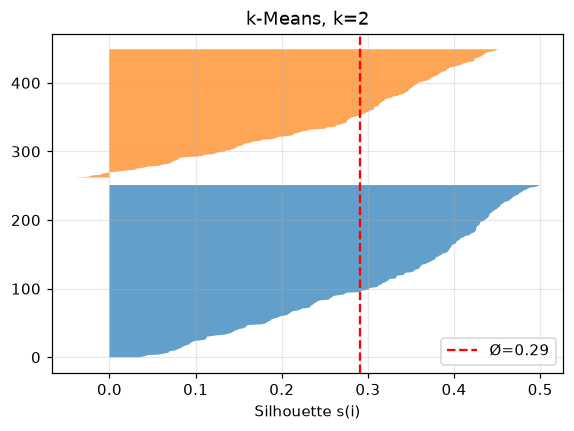

In [8]:
# Silhouetten-Diagramm für die gewählte Lösung k=2
km2 = KMeans(n_clusters=2, n_init=10, random_state=RNG).fit(Xs)
sv = silhouette_samples(Xs, km2.labels_)
fig, ax = plt.subplots(figsize=(6, 4)); y = 0
for c in range(2):
    vals = np.sort(sv[km2.labels_ == c])
    ax.fill_betweenx(np.arange(y, y+len(vals)), 0, vals, alpha=0.7)
    y += len(vals) + 10
ax.axvline(sv.mean(), ls="--", c="red", label=f"Ø={sv.mean():.2f}")
ax.set_xlabel("Silhouette s(i)"); ax.set_title("k-Means, k=2"); ax.legend(); plt.show()

Elbow (schwacher Knick bei $k=2$–$3$) und Silhouette (Maximum bei **$k=2$**, 0,29) deuten beide auf eine **grobe Zweiteilung**. Der Silhouettenwert von 0,29 ist *moderat* — konsistent mit dem t-SNE-Bild überlappender Wolken. Es gibt keine kristallklaren Cluster; es gibt einen dominanten Zwei-Gruppen-Kontrast plus Grauzone.

## 5 · Gaussian Mixture / EM: Modellwahl über BIC

Das GMM (Skript 2.7) modelliert die Daten als Mischung von Gauß-Komponenten und liefert **weiche** Zuordnungen (Verantwortlichkeiten $\gamma_{ik}$). Anders als k-Means erlaubt es über die Kovarianzmatrix **elliptische, unterschiedlich große und rotierte** Cluster — passend zu unseren länglichen log-normalen Blobs.

Modellwahl über den **BIC**: $\mathrm{BIC} = -2\,\ell(\hat\theta) + p\log n$, wobei $p$ die Zahl freier Parameter ist. Der BIC bestraft Komplexität und approximiert die marginale Modell-Evidenz — wir minimieren ihn **gemeinsam über Komponentenzahl und Kovarianztyp**.

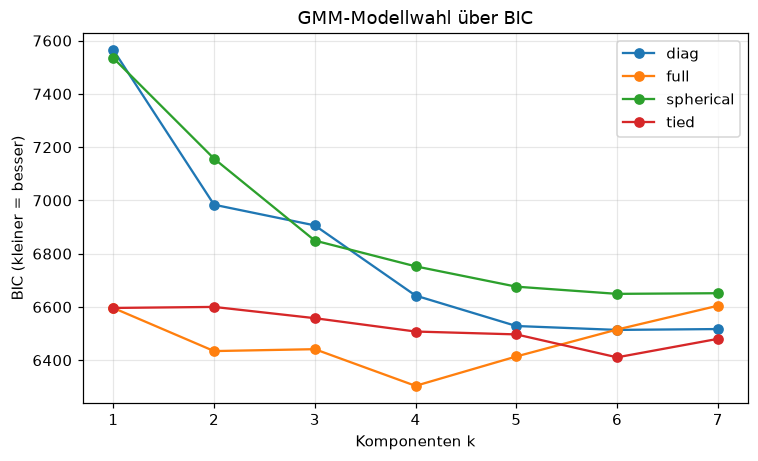

BIC-Minimum: {'cov': 'full', 'k': 4, 'BIC': 6303.805747507101, 'AIC': 5850.173752819835}


In [9]:
from sklearn.mixture import GaussianMixture

rows = []
for cov in ["full", "tied", "diag", "spherical"]:
    for k in range(1, 8):
        g = GaussianMixture(n_components=k, covariance_type=cov,
                            n_init=5, random_state=RNG).fit(Xs)
        rows.append((cov, k, g.bic(Xs), g.aic(Xs)))
bic = pd.DataFrame(rows, columns=["cov", "k", "BIC", "AIC"])

fig, ax = plt.subplots(figsize=(7, 4.3))
for cov, sub in bic.groupby("cov"):
    ax.plot(sub.k, sub.BIC, "o-", label=cov)
ax.set_xlabel("Komponenten k"); ax.set_ylabel("BIC (kleiner = besser)")
ax.set_title("GMM-Modellwahl über BIC"); ax.legend(); plt.tight_layout(); plt.show()

best = bic.loc[bic.BIC.idxmin()]
best_k, best_cov = int(best["k"]), str(best["cov"])
print("BIC-Minimum:", best.to_dict())

In [10]:
# Zwei Lesarten: BIC-Optimum (feinkörnig) vs. die grobe 2-Segment-Sicht
gmm_bic = GaussianMixture(n_components=best_k, covariance_type=best_cov,
                          n_init=5, random_state=RNG).fit(Xs)
gmm2 = GaussianMixture(n_components=2, covariance_type="full",
                       n_init=5, random_state=RNG).fit(Xs)
resp = gmm2.predict_proba(Xs)
print("GMM (k=%d, %s): Silhouette=%.3f"
      % (best_k, best_cov, silhouette_score(Xs, gmm_bic.predict(Xs))))
print("Weiche Zuordnung, Beispiel-Verantwortlichkeiten (erste 5 Kunden, k=2):")
print(np.round(resp[:5], 2))
print("Anteil 'unsicherer' Kunden (max. Verantwortlichkeit < 0.8): %.1f %%"
      % (100 * np.mean(resp.max(1) < 0.8)))

GMM (k=4, full): Silhouette=0.172
Weiche Zuordnung, Beispiel-Verantwortlichkeiten (erste 5 Kunden, k=2):
[[0.98 0.02]
 [0.97 0.03]
 [0.95 0.05]
 [0.   1.  ]
 [0.71 0.29]]
Anteil 'unsicherer' Kunden (max. Verantwortlichkeit < 0.8): 6.1 %


**Der lehrreiche Konflikt.** Der BIC wird bei **$k=4$** (Kovarianztyp `full`) minimal — statistisch gibt es also vier Gauß-Komponenten (Sub-Segmente, z. B. Retail in "reine Supermärkte" vs. "Cafés mit Ladentheke"). Die *grobe* Zweiteilung ($k=2$) ist aber die geschäftlich dominante Struktur. Beide Aussagen sind wahr — sie beantworten verschiedene Fragen ("wie viele statistische Komponenten?" vs. "welche Haupt-Zielgruppen?"). Die weiche Zuordnung zeigt zudem, dass ein spürbarer Anteil der Kunden (hier ~6 %) **im Übergang** liegt (max. Verantwortlichkeit < 0,8) — Information, die eine harte Zuordnung (k-Means) verschenkt.

## 6 · DBSCAN: ein *instruktives Scheitern*

DBSCAN (Skript 2.8) definiert Cluster als **dichte Regionen, getrennt durch dünn besetzte Regionen**. Parameter: `min_samples` (Heuristik: $\ge 2\cdot\dim = 12$) und `eps`, das wir über den **k-Distanz-Plot** wählen (sortierte Distanz zum 12.-nächsten Nachbarn; der "Knick" markiert die Grenze dichter/dünner Bereiche).

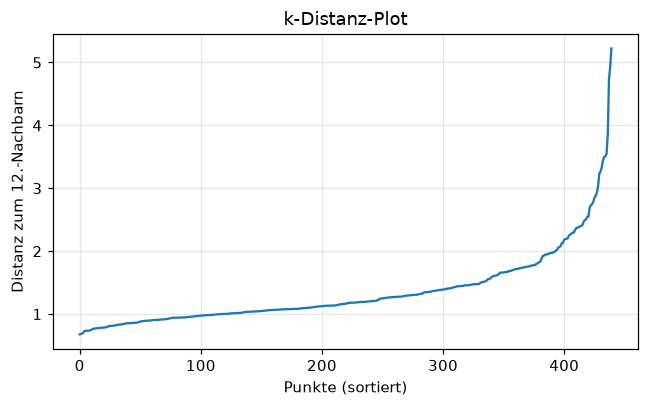

eps=1.8: Cluster=1, Rauschen=27
eps=2.0: Cluster=1, Rauschen=17
eps=2.2: Cluster=1, Rauschen=11
eps=2.5: Cluster=1, Rauschen=7
eps=3.0: Cluster=1, Rauschen=3


In [11]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

min_samples = 2 * Xs.shape[1]   # 12
kd = np.sort(NearestNeighbors(n_neighbors=min_samples)
             .fit(Xs).kneighbors(Xs)[0][:, -1])

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(kd); ax.set_xlabel("Punkte (sortiert)")
ax.set_ylabel(f"Distanz zum {min_samples}.-Nachbarn"); ax.set_title("k-Distanz-Plot")
plt.tight_layout(); plt.show()

for eps in [1.8, 2.0, 2.2, 2.5, 3.0]:
    lab = DBSCAN(eps=eps, min_samples=min_samples).fit(Xs).labels_
    nclu = len(set(lab)) - (1 if -1 in lab else 0)
    print(f"eps={eps}: Cluster={nclu}, Rauschen={int((lab==-1).sum())}")

**Ergebnis: DBSCAN findet bei *jedem* `eps` genau einen Cluster plus Rauschpunkte.** Das ist kein Bug, sondern die korrekte Antwort auf eine falsch gestellte Frage. Der k-Distanz-Plot hat **keinen scharfen Knick** — die Dichte fällt kontinuierlich ab. Unsere Daten sind (nach log/z-Score) **ein einziger zusammenhängender, unterschiedlich dichter Blob**, kein System dichter Inseln in leerem Raum. DBSCANs Grundannahme ist verletzt.

Die Lehre: Die Wahl des Algorithmus ist eine **Modellannahme über die Cluster-Form**. k-Means/GMM ("Cluster = kompakte Zentren/Gaußglocken") passen hier; DBSCAN ("Cluster = Dichteinseln") passt nicht. Ein Verfahren zu benutzen, dessen Annahme die Daten verletzen, liefert kein besseres Ergebnis — es liefert ein bedeutungsloses.

## 7 · Hierarchisch (Ward) + Dendrogramm

Ward-Linkage (Skript 2.8) verschmilzt bottom-up die zwei Cluster, deren Fusion die WCSS am wenigsten erhöht — konzeptuell die agglomerative Schwester von k-Means. Der Vorteil: Das **Dendrogramm** zeigt die Cluster-Struktur über *alle* Auflösungen gleichzeitig; die Höhe der Fusionen ($k$ = Zahl der Schnitte einer horizontalen Linie) macht sichtbar, welche Zahl von Clustern "natürlich" ist.

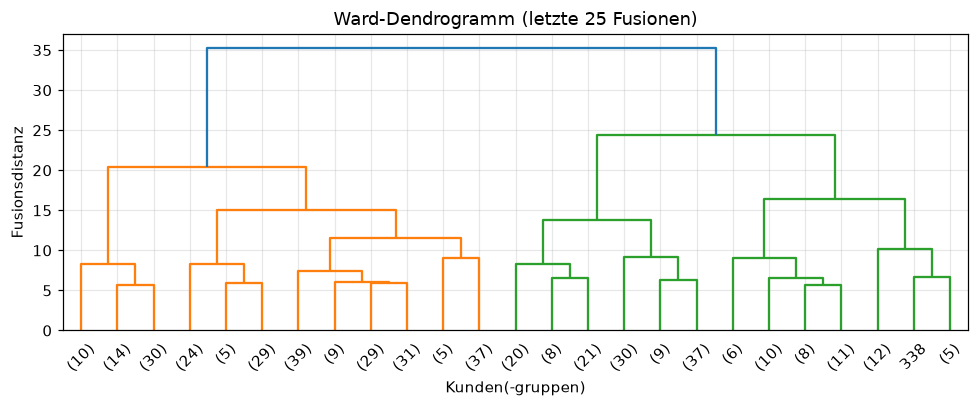

k=2: Silhouette=0.258  ARI(Channel)=0.539
k=3: Silhouette=0.255  ARI(Channel)=0.549
k=4: Silhouette=0.202  ARI(Channel)=0.390


In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

Zl = linkage(Xs, method="ward")
fig, ax = plt.subplots(figsize=(9, 3.8))
dendrogram(Zl, truncate_mode="lastp", p=25, ax=ax, color_threshold=0.7*Zl[:,2].max())
ax.set_title("Ward-Dendrogramm (letzte 25 Fusionen)")
ax.set_xlabel("Kunden(-gruppen)"); ax.set_ylabel("Fusionsdistanz")
plt.tight_layout(); plt.show()

for k in (2, 3, 4):
    lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(Xs)
    print(f"k={k}: Silhouette={silhouette_score(Xs,lab):.3f}  "
          f"ARI(Channel)={adjusted_rand_score(channel,lab):.3f}")

Der größte Distanzsprung im Dendrogramm liegt beim Schnitt in **zwei** Hauptäste — dieselbe Zweiteilung wie bei k-Means und GMM. Ein zweiter, kleinerer Sprung stützt $k=3$. Die Verfahren sind sich also über die *grobe* Struktur einig, streiten nur über die Feinauflösung.

## 8 · Validierung: internes vs. externes Kriterium

Jetzt der Kern des Moduls — Clustering ist unüberwacht, also brauchen wir Kriterien für "gut":

- **Intern** (nur aus $X$): **Silhouette** (↑), **Davies-Bouldin** (↓), **Calinski-Harabasz** (↑). Messen Kompaktheit/Trennung, ohne Wahrheit.
- **Extern** (gegen die zurückgehaltene `Channel`-Wahrheit): **Adjusted Rand Index** (ARI) — misst Übereinstimmung zweier Partitionen, zufallskorrigiert (0 = zufällig, 1 = identisch). Das ist der ehrliche Test: *Hat das Verfahren die reale Horeca/Retail-Struktur wiederentdeckt?*

In [13]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

def scores(lab):
    ok = len(set(lab) - {-1}) > 1
    return dict(
        Silhouette=silhouette_score(Xs, lab) if ok else np.nan,
        DaviesBouldin=davies_bouldin_score(Xs, lab) if ok else np.nan,
        CalinskiHarabasz=calinski_harabasz_score(Xs, lab) if ok else np.nan,
        ARI_Channel=adjusted_rand_score(channel, lab))

labels = {
    "kMeans k=2":  KMeans(2, n_init=10, random_state=RNG).fit_predict(Xs),
    "GMM k=2 full": gmm2.predict(Xs),
    "GMM k=4 (BIC)": gmm_bic.predict(Xs),
    "Ward k=2":    AgglomerativeClustering(2, linkage="ward").fit_predict(Xs),
    "DBSCAN eps=2.5": DBSCAN(eps=2.5, min_samples=12).fit_predict(Xs),
}
table = pd.DataFrame({name: scores(l) for name, l in labels.items()}).T
table.round(3)

,Silhouette,DaviesBouldin,CalinskiHarabasz,ARI_Channel
kMeans k=2,0.290,1.352,189.050,0.514
GMM k=2 full,0.266,1.391,165.420,0.622
GMM k=4 (BIC),0.172,2.341,75.726,0.391
Ward k=2,0.258,1.600,134.624,0.539
DBSCAN eps=2.5,NaN,NaN,NaN,-0.016


**Lies diese Tabelle genau — sie ist das Ergebnis des Projekts:**

1. **GMM (k=2, full) gewinnt beim ARI (≈ 0,62)** und schlägt k-Means (≈ 0,51) und Ward (≈ 0,54) *deutlich*. Warum? Die wahren Segmente sind **elliptisch und unterschiedlich groß/gestreckt** (log-normale Ausgaben). k-Means erzwingt sphärische Cluster gleicher Größe und schneidet den Übergangsbereich geometrisch falsch; das GMM mit voller Kovarianz passt sich der Form an. **Das flexiblere Formmodell entdeckt die Geschäftslogik am treusten.**
2. **Internes und externes Kriterium können auseinanderlaufen.** GMM k=4 hat den besten BIC, aber einen schlechteren ARI (es zerlegt die zwei Channels in Sub-Segmente). "Statistisch mehr Komponenten" ≠ "besser für die Geschäftsfrage". Man muss wissen, *welche* Frage man stellt.
3. **DBSCAN** kollabiert auf *einen* Cluster (plus Rauschen), sodass die internen Maße gar nicht definiert sind (NaN — Silhouette braucht ≥ 2 Cluster). Sein ARI ≈ 0 bestätigt: Es hat die Struktur **nicht** gefunden.

Kein Kriterium ist allein ausreichend: Silhouette misst Geometrie, BIC misst Likelihood-Sparsamkeit, ARI misst Übereinstimmung mit externer Wahrheit. Ein Praktiker trianguliert.

## 9 · Geschäftliche Interpretation: die Segmente benennen

Ein Clustering ist erst dann etwas wert, wenn man die Cluster *inhaltlich* versteht. Wir nehmen die Gewinner-Lösung (GMM k=2) und beschreiben die Segmente über ihre **Median-Ausgaben pro Kategorie** (zurück im interpretierbaren Geld-Raum) sowie über die Zusammensetzung nach dem wahren `Channel`.

Median-Jahresausgaben je Segment (Geldeinheiten):
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Segment                                                                
0        10272.0  1992.0   2506.0  2282.0             338.0       782.0
1         5540.0  7482.0  11722.0   973.0            4915.0      1339.0

Kreuztabelle Segment × wahrer Channel:
Channel  Horeca  Retail
Segment                
0           263      11
1            35     131


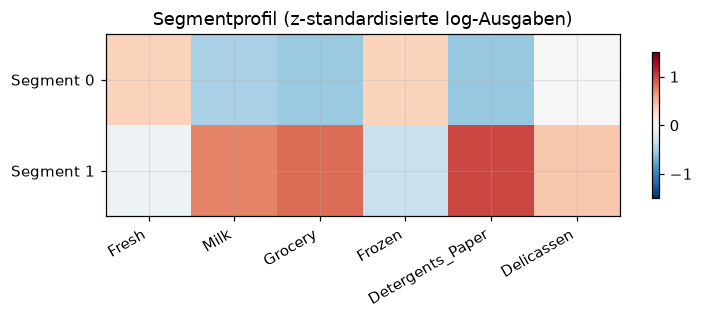

In [14]:
lab = gmm2.predict(Xs)
# Cluster so umbenennen, dass Cluster 0 der Horeca-lastige ist (Vergleichbarkeit)
if df.loc[lab==0, "Detergents_Paper"].median() > df.loc[lab==1, "Detergents_Paper"].median():
    lab = 1 - lab

prof = df[FEATURES].copy(); prof["Segment"] = lab
med = prof.groupby("Segment")[FEATURES].median().round(0)
print("Median-Jahresausgaben je Segment (Geldeinheiten):"); print(med)
print("\nKreuztabelle Segment × wahrer Channel:")
print(pd.crosstab(pd.Series(lab, name="Segment"),
                  pd.Series(np.where(channel==0,"Horeca","Retail"), name="Channel")))

fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(scaler.transform(np.log1p(med.values)), cmap="RdBu_r",
               aspect="auto", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(6)); ax.set_xticklabels(FEATURES, rotation=30, ha="right")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Segment 0", "Segment 1"])
ax.set_title("Segmentprofil (z-standardisierte log-Ausgaben)")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

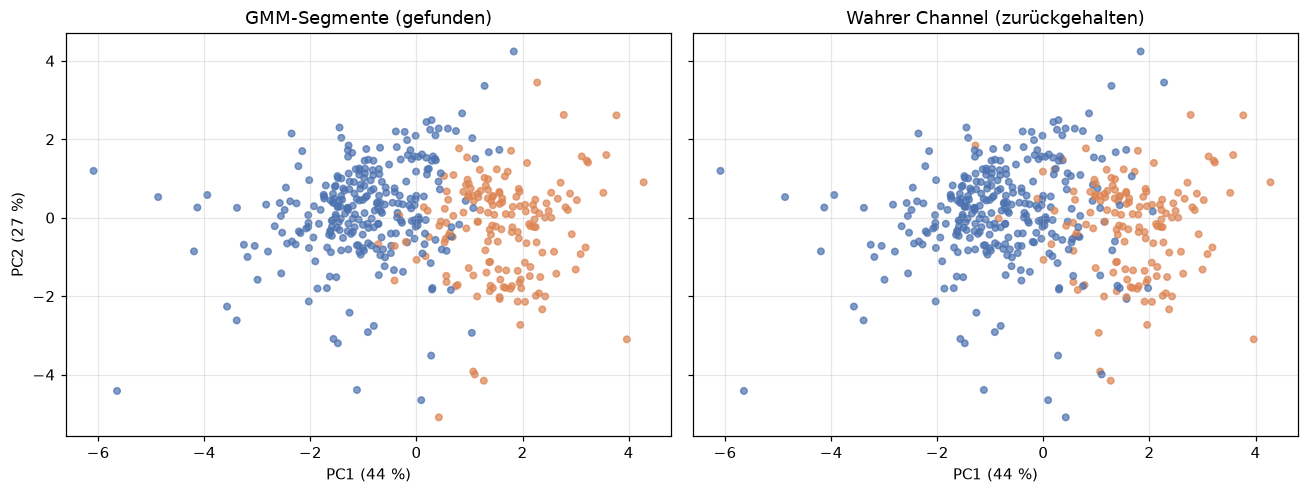

In [15]:
# Finale Sicht: PCA-Projektion, links gefundene Segmente, rechts wahrer Channel
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
a1.scatter(Z[:,0], Z[:,1], c=np.where(lab==0,"#4C72B0","#DD8452"), s=18, alpha=0.7)
a1.set_title("GMM-Segmente (gefunden)")
a2.scatter(Z[:,0], Z[:,1], c=np.where(channel==0,"#4C72B0","#DD8452"), s=18, alpha=0.7)
a2.set_title("Wahrer Channel (zurückgehalten)")
for a in (a1, a2): a.set_xlabel(f"PC1 ({evr[0]*100:.0f} %)")
a1.set_ylabel(f"PC2 ({evr[1]*100:.0f} %)")
plt.tight_layout(); plt.show()

**Die beiden Segmente, in Worten:**

- **Segment 0 — „Gastronomie / Horeca"**: hohe `Fresh`- und `Frozen`-Ausgaben, niedrige `Grocery`/`Detergents_Paper`. Restaurants, Cafés, Hotels — sie kaufen frische und tiefgekühlte Ware, kaum Supermarkt-Sortiment. Überwiegend Channel = Horeca.
- **Segment 1 — „Einzelhandel / Retail"**: hohe `Milk`, `Grocery`, `Detergents_Paper` — der Supermarkt-Warenkorb mit haltbarer Ware und Non-Food. Überwiegend Channel = Retail.

Die rechte/linke PCA-Karte zeigt es unmittelbar: Die *rein aus Ausgaben* gefundenen Segmente decken sich weitgehend mit der zurückgehaltenen `Channel`-Wahrheit — mit einer echten Übergangszone in der Mitte (Mischbetriebe), die die weiche GMM-Zuordnung korrekt als "unsicher" markiert.

**Geschäftlicher Nutzen:** Der Distributor kann ohne Kundenbefragung Logistik (Frische- vs. Trockenlager), Sortiment und Marketing pro Segment ausrichten — und die Übergangskunden gezielt als Cross-Selling-Chance behandeln.

## 10 · Fazit

| Frage | Antwort in diesem Projekt |
|---|---|
| Wie viele Segmente? | Grob **2** (Horeca vs. Retail) — konsistent über k-Means, GMM, Ward; feinkörnig deutet der BIC auf ~4 Sub-Segmente. |
| Welches Verfahren? | **GMM mit voller Kovarianz** — höchster ARI, weil elliptische Cluster zur log-normalen Ausgabenstruktur passen und weiche Zuordnungen die Übergangszone abbilden. |
| Warum nicht DBSCAN? | Die Daten sind *ein* dichter Blob variabler Dichte, keine getrennten Dichteinseln — DBSCANs Annahme ist verletzt. |
| Wie validiert? | Intern (Silhouette/DB/CH) **und** extern (ARI gegen zurückgehaltenen `Channel`); beide zusammen, nie eines allein. |

**Kernbotschaft des Moduls:** Unüberwachtes Lernen liefert nicht *die* Wahrheit, sondern eine Antwort, die von deinen **Annahmen über Cluster-Form** (Algorithmuswahl), deiner **Vorverarbeitung** (log/z-Score) und deinem **Gütekriterium** abhängt. Kompetenz heißt hier: diese Annahmen bewusst wählen, ihre Verletzung erkennen (DBSCAN!) und die Ergebnisse mehrerer Verfahren gegen ein externes Kriterium triangulieren.